In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib
from sklearn.model_selection import train_test_split 

In [274]:
dataset_name="gold"

In [275]:
df=pd.read_csv(f"../data/after_F_eng/{dataset_name}_F_Eng.csv")

In [276]:
df.head()

,Date,Open,High,Low,Close,Volume,Asset_Name,MA_7,MA_30,Daily_Return,...,Year,DayOfWeek,Quarter,Close_lag1,Close_lag2,Close_lag7,EMA_7,Price_Range,Open_Close_Diff,Rolling_STD_7
0,2004-07-23,394.3,395.0,386.5,389.3,1899,Gold,399.071429,396.656667,-0.010170,...,2004,4,3,393.3,396.1,404.8,396.912376,8.5,5.0,6.312082
1,2004-07-26,389.3,392.1,388.1,389.8,1992,Gold,397.171429,396.846667,0.001284,...,2004,0,3,389.3,393.3,403.1,395.134282,4.0,-0.5,6.874037
2,2004-07-27,390.5,393.1,385.1,386.6,3054,Gold,394.385714,396.973333,-0.008209,...,2004,1,3,389.8,389.3,406.1,393.000711,8.0,3.9,6.598340
3,2004-07-28,386.1,389.6,384.5,387.3,3205,Gold,391.885714,396.930000,0.001811,...,2004,2,3,386.6,389.8,404.8,391.575533,5.1,-1.2,5.151514
4,2004-07-29,387.3,390.8,385.3,387.1,2521,Gold,389.928571,397.040000,-0.000516,...,2004,3,3,387.3,386.6,400.8,390.456650,5.5,0.2,3.555613


In [277]:
df["Target"] = df["Close"].shift(-1)

In [278]:
df = df.dropna()

In [279]:
y = df["Target"]

In [280]:
X = df.drop(
    columns=[
        "Close",
        "Target",
        "Date",
        "Asset_Name"
    ]
)

In [281]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [282]:
scaler = StandardScaler()

In [283]:
X_train_scaled = scaler.fit_transform(
    X_train
)

In [284]:
X_test_scaled = scaler.transform(
    X_test
)

LINEAR REGRESSION

In [285]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

In [286]:
print("Linear Regression Results")
print()

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression Results

MAE: 19.645025386094012
RMSE: 38.16659815759665
R2: 0.9971894274879874


In [287]:
corr_with_target = df.corr(
    numeric_only=True
)["Target"].sort_values(
    ascending=False
)

print(corr_with_target)

Target             1.000000
Close              0.999535
Low                0.999452
High               0.999331
Open               0.999201
Close_lag1         0.999079
EMA_7              0.999019
MA_7               0.998757
Close_lag2         0.998680
Close_lag7         0.996719
MA_30              0.996347
Year               0.817278
Volume             0.630056
Price_Range        0.602359
Rolling_STD_7      0.563901
Daily_Return       0.044733
Volatility_7       0.012985
Quarter            0.010256
Month              0.008066
Day                0.008048
DayOfWeek         -0.000802
Open_Close_Diff   -0.084991
Name: Target, dtype: float64


RANDOM FOREST

In [288]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_pred = rf_model.predict(
    X_test_scaled
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

In [289]:
print("Random Forest Results")
print()

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results

MAE: 444.8234136239787
RMSE: 795.5114670203358
R2: -0.22101437836576854


XGBOOST

In [290]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgb_model.fit(
    X_train_scaled,
    y_train
)
xgb_pred = xgb_model.predict(
    X_test_scaled
)
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)
xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

In [291]:
print("XGBoost Results")
print()

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Results

MAE: 457.85588280895206
RMSE: 813.8370549436542
R2: -0.2779174763971959


Comparison Table

In [292]:
results = {
    "Linear Regression": {
        "MAE": lr_mae,
        "RMSE": lr_rmse,
        "R2": lr_r2,
        "Predictions": lr_pred
    },

    "Random Forest": {
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2,
        "Predictions": rf_pred
    },

    "XGBoost": {
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "R2": xgb_r2,
        "Predictions": xgb_pred
    }
}

In [293]:
best_model = max(
    results,
    key=lambda x: results[x]["R2"]
)

In [294]:
print("Best Model:")
print(best_model)

Best Model:
Linear Regression


In [295]:
best_predictions = results[
    best_model
]["Predictions"]

In [296]:
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

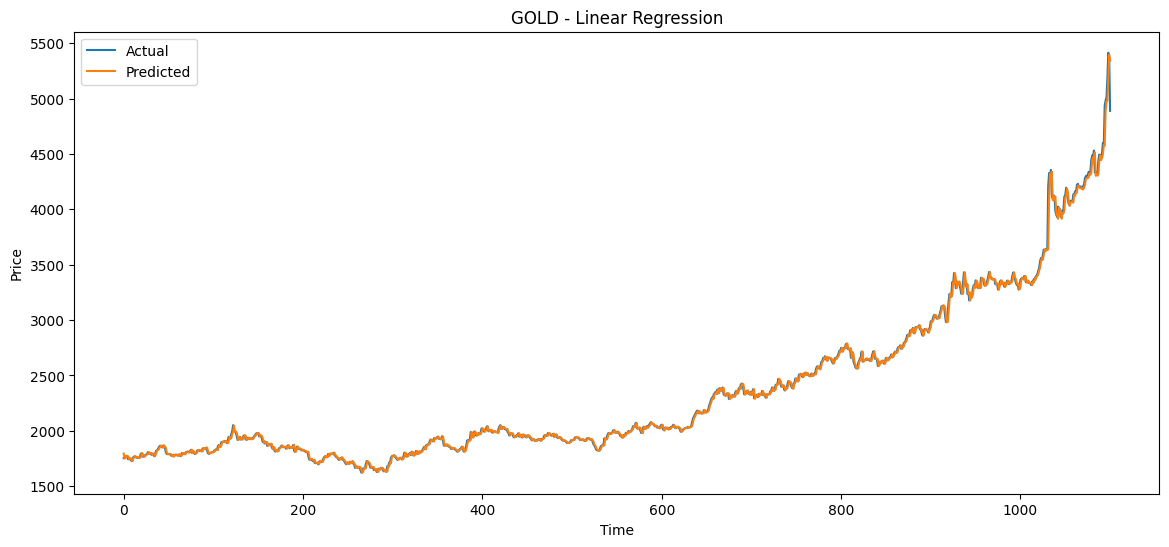

In [297]:
plt.figure(figsize=(14,6))

plt.plot(
    pred_df["Actual"].values,
    label="Actual"
)

plt.plot(
    pred_df["Predicted"].values,
    label="Predicted"
)

plt.title(
    f"{dataset_name.upper()} - {best_model}"
)

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()